In [7]:
root_dir = '/vast/palmer/home.grace/zz436/neural_priming/'
import sys
sys.path.append(root_dir)
from priming_utils import *

import torch
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

from dataclasses import dataclass
from typing import Optional
import gc
import seaborn as sns
from tqdm.auto import tqdm
from transformer_lens import HookedTransformer, utils

torch.set_grad_enabled(True)

In [11]:
SIZE = 'large'
PRONOUN = False
file_Pronoun = 'Pronoun' if PRONOUN else 'NoPronoun'
batch_size = 10
PADDING = True

model_name = f'gpt2-{SIZE}'
model = HookedTransformer.from_pretrained(model_name, device=device)

print(torch.cuda.get_device_properties(0).name)
print(torch.cuda.get_device_properties(0).total_memory/1000000)
print(torch.cuda.memory_reserved(device=device)/1000000)

Loaded pretrained model gpt2-large into HookedTransformer
NVIDIA A100-PCIE-40GB
42297.786368
7071.596544


# Prepare the filler sentences `fillers_shifted` with equal number of tokens

In [12]:
filler_path = f'{root_dir}fine-tuning/fillers_big.txt'

with open(filler_path, 'r') as f:
    fillers = [line.strip() for line in f.readlines()]
print(f'The set of {len(fillers)} fillers.')

long_tensor = torch.tensor([]).to(device)
for filler in fillers:
    long_tensor = torch.cat((long_tensor, model.to_tokens(filler+' ')[0, 1:]))
long_tensor = torch.cat((long_tensor, model.to_tokens("The two objectives are")[0, 1:]))
long_tensor.shape
#long_tensor = torch.cat((long_tensor, model.to_tokens("The two objectives are linked")[0, 1:]))

The set of 30 fillers.


torch.Size([3330])

In [13]:
long_tensor = long_tensor.reshape(batch_size, -1).to(torch.int64)
bos = torch.full((batch_size, 1), 50257).to(device)
input_tensor = torch.cat((bos, long_tensor), dim=1)
fillers_shifted = [''.join(model.to_str_tokens(input_tensor[i])) for i in range(input_tensor.shape[0])]

FILLERS = fillers if PADDING else fillers_shifted

with torch.no_grad():
    if SIZE == 'small':
        raw_loss = model(FILLERS, return_type="loss").detach()
    else:
        raw_loss = []
        for filler in FILLERS:
            raw_loss.append(model(filler, return_type="loss").detach())

In [14]:
raw_loss

[tensor(3.6683, device='cuda:0'),
 tensor(2.5186, device='cuda:0'),
 tensor(3.1361, device='cuda:0'),
 tensor(3.5448, device='cuda:0'),
 tensor(4.4669, device='cuda:0'),
 tensor(2.9923, device='cuda:0'),
 tensor(3.4389, device='cuda:0'),
 tensor(3.9911, device='cuda:0'),
 tensor(2.8367, device='cuda:0'),
 tensor(3.5751, device='cuda:0'),
 tensor(3.5976, device='cuda:0'),
 tensor(3.1210, device='cuda:0'),
 tensor(3.5141, device='cuda:0'),
 tensor(3.1742, device='cuda:0'),
 tensor(3.6149, device='cuda:0'),
 tensor(3.0744, device='cuda:0'),
 tensor(3.5694, device='cuda:0'),
 tensor(3.3461, device='cuda:0'),
 tensor(2.4857, device='cuda:0'),
 tensor(3.4706, device='cuda:0'),
 tensor(3.1326, device='cuda:0'),
 tensor(2.5762, device='cuda:0'),
 tensor(2.8619, device='cuda:0'),
 tensor(4.5936, device='cuda:0'),
 tensor(3.2772, device='cuda:0'),
 tensor(5.2775, device='cuda:0'),
 tensor(2.9394, device='cuda:0'),
 tensor(3.2130, device='cuda:0'),
 tensor(2.7932, device='cuda:0'),
 tensor(2.9681

In [15]:
@dataclass
class HookedTransformerTrainConfig:
    num_epochs: int
    batch_size: int
    lr: float = 1e-5
    lamb: float = 0.0
    seed: int = 0
    
    momentum: float = 0.0
    max_grad_norm: Optional[float] = None
    weight_decay: Optional[float] = None
    optimizer_name: str = "Adam"
    
    device: Optional[str] = None
    warmup_steps: int = 0
    save_every: Optional[int] = None
    save_dir: Optional[str] = None

    print_every: Optional[int] = None
    max_steps: Optional[int] = None

def train(
    model: HookedTransformer,
    config: HookedTransformerTrainConfig,
    dataset: Dataset,
    raw_loss: float
) -> HookedTransformer:
    torch.manual_seed(config.seed)
    model.train()

    if config.device is None:
        config.device = utils.get_device()

    if config.optimizer_name in ["Adam", "AdamW"]:
        # Weight decay in Adam is implemented badly, so use AdamW instead (see PyTorch AdamW docs)
        if config.weight_decay is not None:
            optimizer = optim.AdamW(
                model.parameters(),
                lr=config.lr,
                weight_decay=config.weight_decay,
            )
        else:
            optimizer = optim.Adam(
                model.parameters(),
                lr=config.lr,
            )
    elif config.optimizer_name == "SGD":
        optimizer = optim.SGD(
            model.parameters(),
            lr=config.lr,
            weight_decay=config.weight_decay
            if config.weight_decay is not None
            else 0.0,
            momentum=config.momentum,
        )
    else:
        raise ValueError(f"Optimizer {config.optimizer_name} not supported")

    scheduler = None
    if config.warmup_steps > 0:
        scheduler = optim.lr_scheduler.LambdaLR(
            optimizer,
            lr_lambda=lambda step: min(1.0, step / config.warmup_steps),
        )

    dataloader = DataLoader(dataset, batch_size=config.batch_size, shuffle=True)

    model.to(config.device)
    for epoch in range(1, config.num_epochs + 1):
        samples = 0
        for step, batch in enumerate(dataloader):
            tokens = batch["tokens"].to(config.device)
            loss = model(tokens, return_type="loss")
            loss.backward()

            if SIZE == 'small':
                loss_reg = model(FILLERS, return_type="loss")
                loss = config.lamb * ((loss_reg - raw_loss)**2)
                loss.backward()
                print(f'At epoch {epoch}, AFTER backward: {torch.cuda.memory_reserved(device=device)/1000000}')
            else:
                for idx, filler in enumerate(FILLERS):
                    loss_reg = model(filler, return_type="loss")
                    loss = config.lamb * ((loss_reg - raw_loss[idx])**2) # may want to divide by 30 if we think this as averaging
                    loss.backward()
            print(torch.cuda.memory_reserved(device=device)/1000000)
            
            
            if config.max_grad_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), config.max_grad_norm)
            optimizer.step()
            if config.warmup_steps > 0:
                assert scheduler is not None
                scheduler.step()
            optimizer.zero_grad()

            samples += tokens.shape[0]

            if config.print_every is not None and step % config.print_every == 0:
                print(f"Epoch {epoch} Samples {samples} Step {step} Loss {loss.item()}")

            if (
                config.save_every is not None
                and step % config.save_every == 0
                and config.save_dir is not None
            ):
                torch.save(model.state_dict(), f"{config.save_dir}/model_{step}.pt")

            if config.max_steps is not None and step >= config.max_steps:
                break
                
        torch.cuda.empty_cache()
        gc.collect()

    return model

class FineTuningDataset(Dataset):
    def __init__(self, data, max_length=15, padding=False):
        self.data = data
        self.max_length = max_length
        self.pad_idx = 50256
        self.padding = padding

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        if not self.padding:
            return {'tokens': model.to_tokens(self.data[idx]).squeeze(0)}
        else:
            temp = model.to_tokens(self.data[idx]).tolist()[0]
            temp.extend([50256] * (self.max_length - len(temp)))
            toks = torch.tensor(temp)
            return {'tokens': toks}

def get_log_prob(sentence, output):
    probs = nn.functional.log_softmax(output.squeeze()[:-1, :], dim=-1)
    probs = probs[range(probs.size(0)), model.to_tokens(sentence).squeeze(0).tolist()[1:]]
    return torch.sum(probs).item(), list(probs.cpu().detach().numpy())

# prime is a single sentence
def finetuning(raw_loss, prime):
    raw_model = HookedTransformer.from_pretrained(model_name, device=device)
            
    train_config = HookedTransformerTrainConfig(
        num_epochs=10,
        batch_size=1,
        lr=1e-5,
        lamb = 0.8,
        optimizer_name="AdamW")
    
    dataset = FineTuningDataset([prime])
    adapted_model = train(raw_model, train_config, dataset, raw_loss)

    return adapted_model

In [11]:
l = [-47.83038330078125, -45.99716567993164]
torch.tensor(l).mean().item()

-46.91377258300781

In [16]:
raw_model = HookedTransformer.from_pretrained(model_name, device=device)

targetPD = 'A soldier brought a cup to a scientist.'
targetDO = 'A soldier brought a scientist a cup.'

output_PD = raw_model(targetPD)
output_DO = raw_model(targetDO)


baseline_PD,_ = get_log_prob(targetPD, output_PD)
baseline_DO,_ = get_log_prob(targetDO, output_DO)

print(f'{baseline_PD}, {baseline_DO}')

Loaded pretrained model gpt2-large into HookedTransformer
-47.83038330078125, -45.99716567993164


In [22]:
adapted_model = finetuning(raw_loss, 'The professor made the key for the president.')

output_PD = adapted_model(targetPD)
output_DO = adapted_model(targetDO)

prob_PD,_ = get_log_prob(targetPD, output_PD)
prob_DO,_ = get_log_prob(targetDO, output_DO)

prob_PD - baseline_PD, prob_DO - baseline_DO

Loaded pretrained model gpt2-small into HookedTransformer
Moving model to device:  cuda
10808.721408
12136.218624
12136.218624
12136.218624
12136.218624
12136.218624
12136.218624
12136.218624
12136.218624
12136.218624


(2.2195892333984375, 2.255260467529297)

# No Padding

In [11]:
rec = []
torch.cuda.empty_cache()
gc.collect()

for LAMB in [0.1, 0.5, 1, 5, 10, 20, 50]: #0.1, 
    print(f'############################ Lamb = {LAMB} ############################')
    for LR in [5e-7, 1e-6, 5e-6, 1e-5, 5e-5, 1e-4, 5e-4]:#1e-7, 1e-4, 5e-4
        print(f'########### Lr = {LR} ###########')
        raw_model = HookedTransformer.from_pretrained(model_name, device=device)
        
        train_config = HookedTransformerTrainConfig(
            num_epochs=10,
            batch_size=1,
            lr=LR,
            lamb = LAMB,
            optimizer_name="AdamW")

        data = ['The professor made the key for the president.']
        dataset = FineTuningDataset(data)
        adapted_model = train(raw_model, train_config, dataset, raw_loss)
        output_PD = adapted_model(targetPD)
        output_DO = adapted_model(targetDO)
        
        sen_prob_PD,_ = get_log_prob(targetPD, output_PD)
        sen_prob_DO,_ = get_log_prob(targetDO, output_DO)

        rec.append({'lambda': train_config.lamb,
                    'lr': train_config.lr,
                    'PD': sen_prob_PD - baseline_PD,
                    'DO': sen_prob_DO - baseline_DO})
        #print(f'lambda = {train_config.lamb}, lr = {train_config.lr}, {sen_prob_PD - baseline_PD}, {sen_prob_DO - baseline_DO}')
        torch.cuda.empty_cache()
        gc.collect()
    
df = pd.DataFrame(rec)
df.to_csv(f'{root_dir}fine-tuning/Hyperparameter/Hypersearch_large_no_padding_big.csv', index=False)

############################ Lamb = 0.1 ############################
########### Lr = 5e-07 ###########
Loaded pretrained model gpt2-large into HookedTransformer
Moving model to device:  cuda
21112.029184
28089.253888
28089.253888
28089.253888
28089.253888
28089.253888
28089.253888
28089.253888
28089.253888
28089.253888
########### Lr = 1e-06 ###########
Loaded pretrained model gpt2-large into HookedTransformer
Moving model to device:  cuda
21118.32064
28095.545344
28095.545344
28095.545344
28095.545344
28095.545344
28095.545344
28095.545344
28095.545344
28095.545344
########### Lr = 5e-06 ###########
Loaded pretrained model gpt2-large into HookedTransformer
Moving model to device:  cuda
21118.32064
28095.545344
28095.545344
28095.545344
28095.545344
28095.545344
28095.545344
28095.545344
28095.545344
28095.545344
########### Lr = 1e-05 ###########
Loaded pretrained model gpt2-large into HookedTransformer
Moving model to device:  cuda
21118.32064
28095.545344
28095.545344
28095.545344


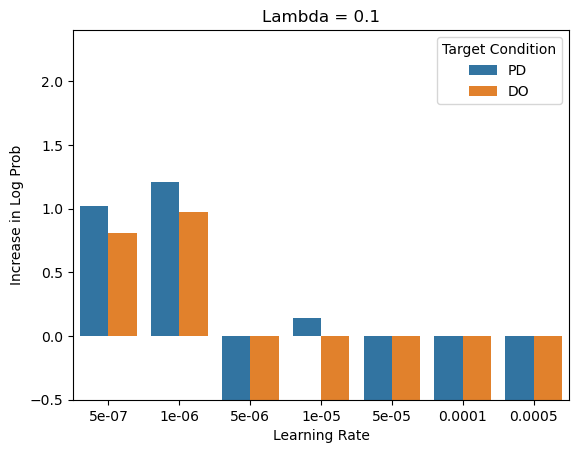

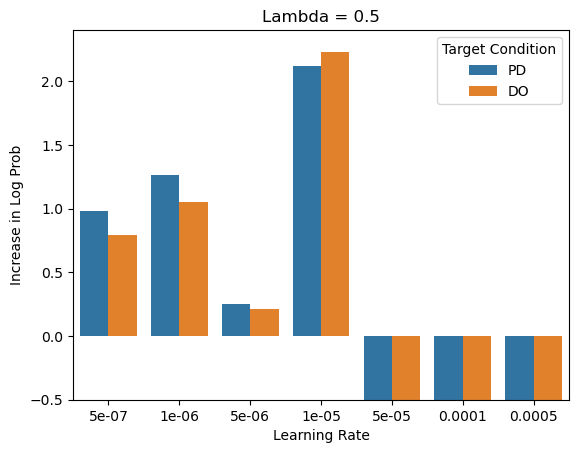

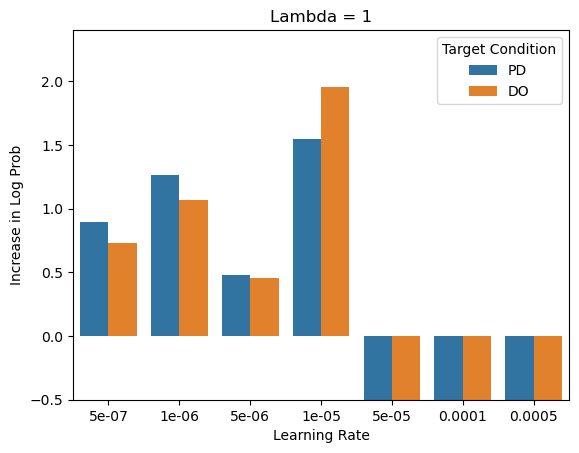

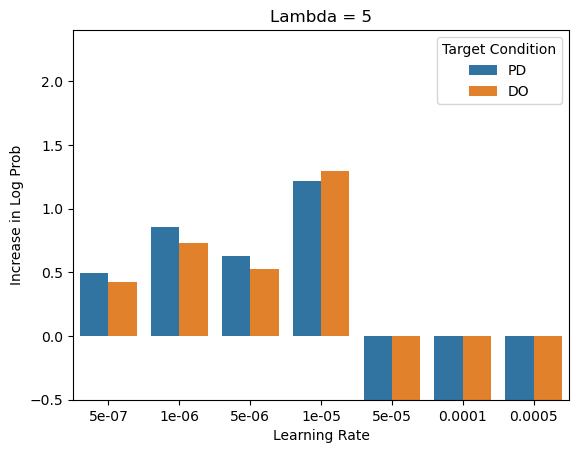

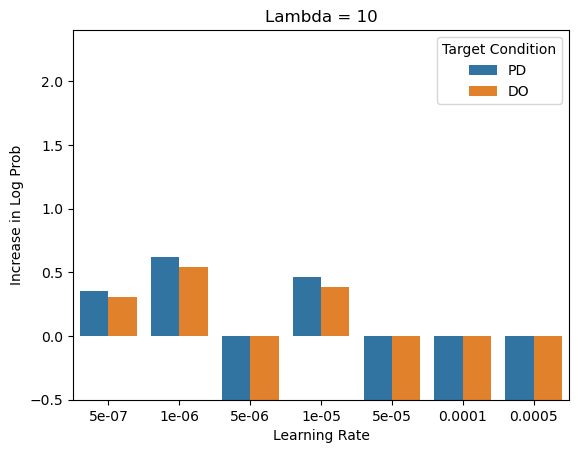

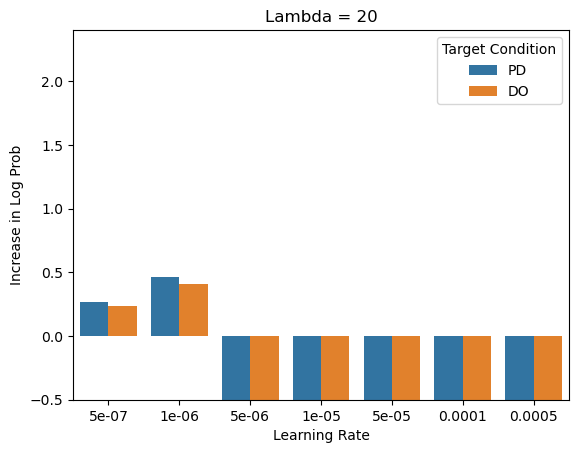

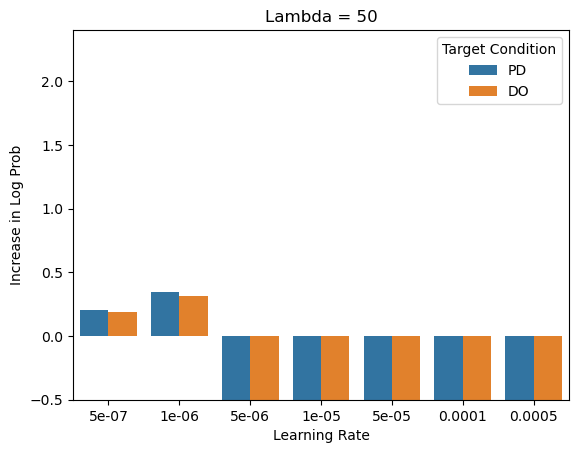

In [16]:
df = pd.read_csv(f'{root_dir}fine-tuning/Hyperparameter/Hypersearch_large_no_padding_big.csv')
# iterate and change the large negative values to -0.5
df.loc[df['PD']<0, 'PD'] = -0.5
df.loc[df['DO']<0, 'DO'] = -0.5

for LAMB in [0.1, 0.5, 1, 5, 10, 20, 50]:
    df_sub = df[df['lambda'] == LAMB][['lr','PD','DO']]
    df_melted = df_sub.melt(id_vars = 'lr', var_name='Target Condition', value_name='Priming Dev')
    sns.barplot(data=df_melted, x='lr', y='Priming Dev', hue='Target Condition')
    plt.ylim(-0.5, 2.4)
    plt.xlabel('Learning Rate')
    plt.ylabel('Increase in Log Prob')
    plt.title(f'Lambda = {LAMB}')
    plt.show()

# With Padding

In [5]:
l = ['the mayor gave the juice to the boy .',
       'the mayor gave the boy the juice .',
       'the child kept the gun for the secretary .',
       'the child kept the secretary the gun .',
       'the cop made the card for the corporation .',
       'the cop made the corporation the card .',
       'the child supplied the beer to the corporation .',
       'the child supplied the corporation the beer .',
       'the brother supplied the beer to the physician .',
       'the brother supplied the physician the beer .',
       'the writer designed the machine for the bishop .',
       'the writer designed the bishop the machine .',
       'the writer bought the pie for the brother .',
       'the writer bought the brother the pie .',
       'the author bought the card for the man .',
       'the author bought the man the card .']

processed = []
for i in range(0,16,2):
    processed.append((l[i].capitalize()[:-2]+'.', l[i+1].capitalize()[:-2]+'.'))
processed

[('The mayor gave the juice to the boy.', 'The mayor gave the boy the juice.'),
 ('The child kept the gun for the secretary.',
  'The child kept the secretary the gun.'),
 ('The cop made the card for the corporation.',
  'The cop made the corporation the card.'),
 ('The child supplied the beer to the corporation.',
  'The child supplied the corporation the beer.'),
 ('The brother supplied the beer to the physician.',
  'The brother supplied the physician the beer.'),
 ('The writer designed the machine for the bishop.',
  'The writer designed the bishop the machine.'),
 ('The writer bought the pie for the brother.',
  'The writer bought the brother the pie.'),
 ('The author bought the card for the man.',
  'The author bought the man the card.')]

In [17]:
rec = []
torch.cuda.empty_cache()
gc.collect()

for LAMB in [0.1, 0.5, 1, 5, 10, 20, 50]: #0.1, 
    print(f'############################ Lamb = {LAMB} ############################')
    for LR in [5e-7, 1e-6, 5e-6, 1e-5, 5e-5, 1e-4, 5e-4]:#1e-7, 1e-4, 5e-4
        print(f'########### Lr = {LR} ###########')
        raw_model = HookedTransformer.from_pretrained(model_name, device=device)
        
        train_config = HookedTransformerTrainConfig(
            num_epochs=10,
            batch_size=1,
            lr=LR,
            lamb = LAMB,
            optimizer_name="AdamW")

        data = ['The professor made the key for the president.']
        dataset = FineTuningDataset(data)
        adapted_model = train(raw_model, train_config, dataset, raw_loss)
        output_PD = adapted_model(targetPD)
        output_DO = adapted_model(targetDO)
        
        sen_prob_PD,_ = get_log_prob(targetPD, output_PD)
        sen_prob_DO,_ = get_log_prob(targetDO, output_DO)

        rec.append({'lambda': train_config.lamb,
                    'lr': train_config.lr,
                    'PD': sen_prob_PD - baseline_PD,
                    'DO': sen_prob_DO - baseline_DO})
        #print(f'lambda = {train_config.lamb}, lr = {train_config.lr}, {sen_prob_PD - baseline_PD}, {sen_prob_DO - baseline_DO}')
        torch.cuda.empty_cache()
        gc.collect()
    
df = pd.DataFrame(rec)
df.to_csv(f'{root_dir}fine-tuning/Hyperparameter/Hypersearch_large_with_padding_big.csv', index=False)

############################ Lamb = 0.1 ############################
########### Lr = 5e-07 ###########
Loaded pretrained model gpt2-large into HookedTransformer
Moving model to device:  cuda
22038.970368
28986.834944
28982.64064
28982.64064
28982.64064
28982.64064
28982.64064
28982.64064
28982.64064
28982.64064
########### Lr = 1e-06 ###########
Loaded pretrained model gpt2-large into HookedTransformer
Moving model to device:  cuda
22034.776064
28982.64064
28980.543488
28982.64064
28980.543488
28980.543488
28980.543488
28980.543488
28980.543488
28980.543488
########### Lr = 5e-06 ###########
Loaded pretrained model gpt2-large into HookedTransformer
Moving model to device:  cuda
22049.456128
28997.320704
28997.320704
28997.320704
28997.320704
28997.320704
28997.320704
28997.320704
28995.223552
28997.320704
########### Lr = 1e-05 ###########
Loaded pretrained model gpt2-large into HookedTransformer
Moving model to device:  cuda
22047.358976
28980.543488
28980.543488
28980.543488
28980.5

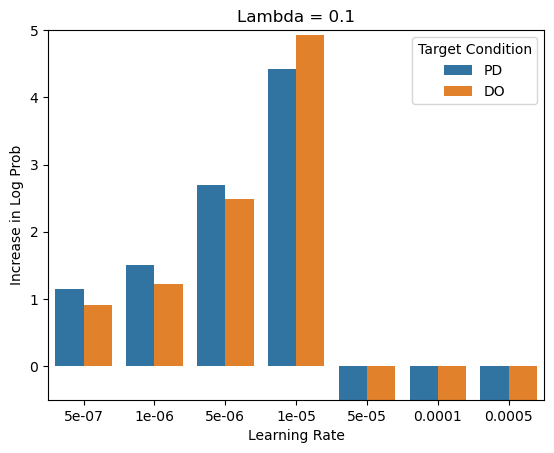

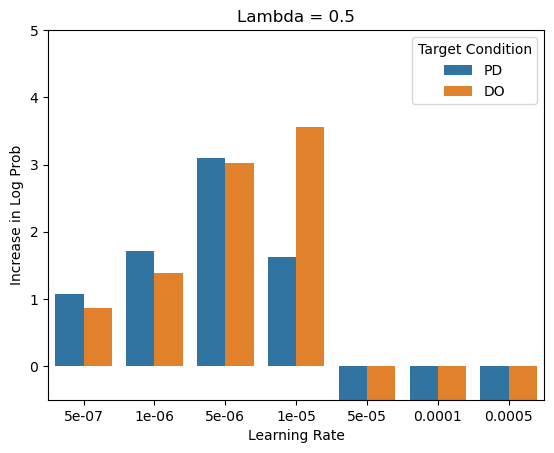

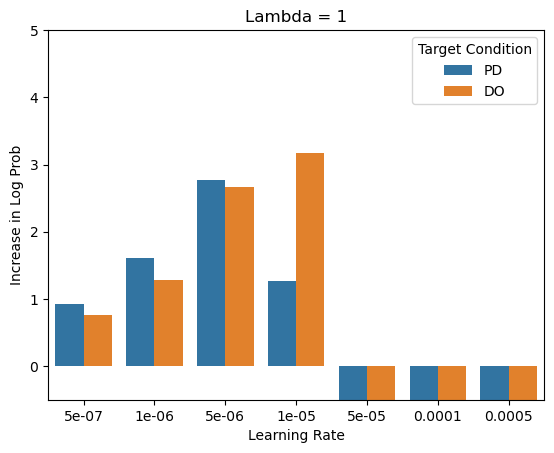

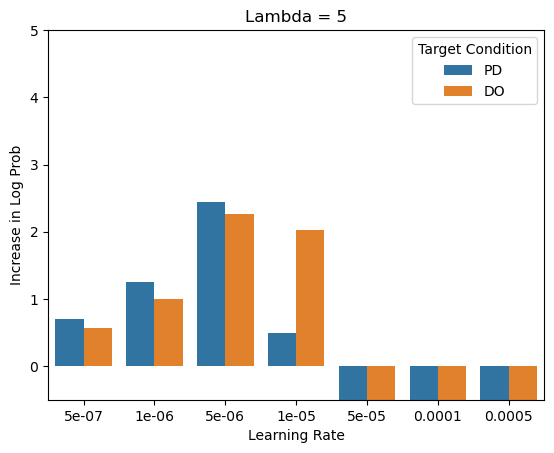

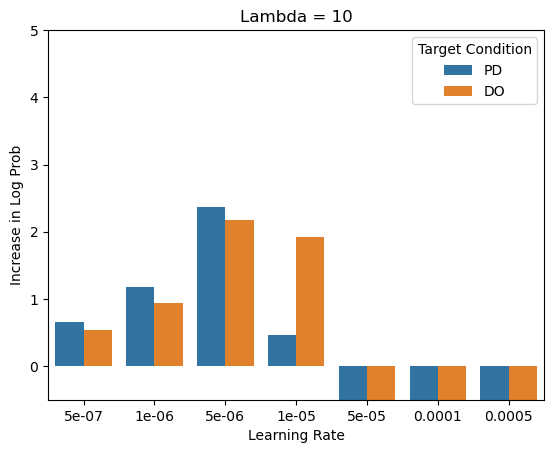

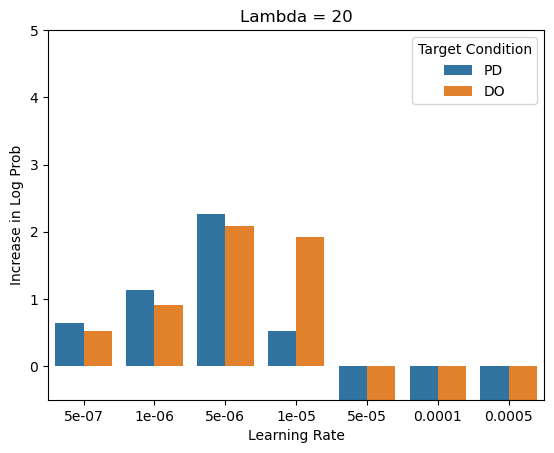

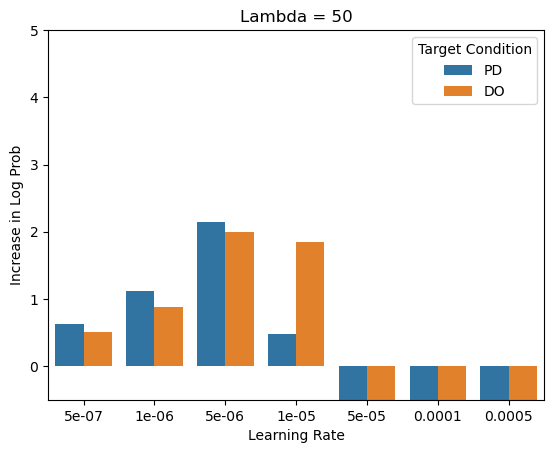

In [6]:
df = pd.read_csv(f'{root_dir}fine-tuning/Hyperparameter/Hypersearch_large_with_padding_big_notsquared.csv')
# iterate and change the large negative values to -0.5
df.loc[df['PD']<0, 'PD'] = -0.5
df.loc[df['DO']<0, 'DO'] = -0.5

for LAMB in [0.1, 0.5, 1, 5, 10, 20, 50]:
    df_sub = df[df['lambda'] == LAMB][['lr','PD','DO']]
    df_melted = df_sub.melt(id_vars = 'lr', var_name='Target Condition', value_name='Priming Dev')
    sns.barplot(data=df_melted, x='lr', y='Priming Dev', hue='Target Condition')
    plt.ylim(-0.5, 5)
    plt.xlabel('Learning Rate')
    plt.ylabel('Increase in Log Prob')
    plt.title(f'Lambda = {LAMB}')
    plt.show()

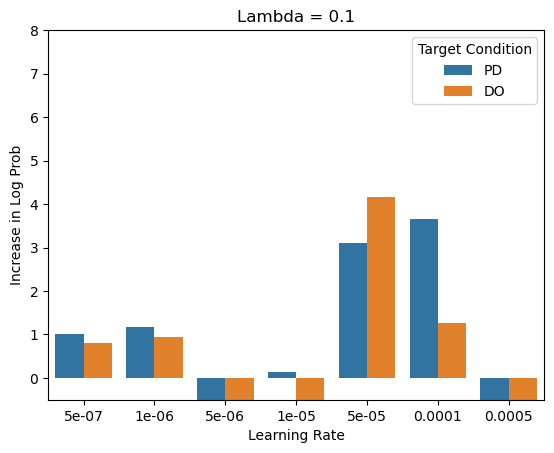

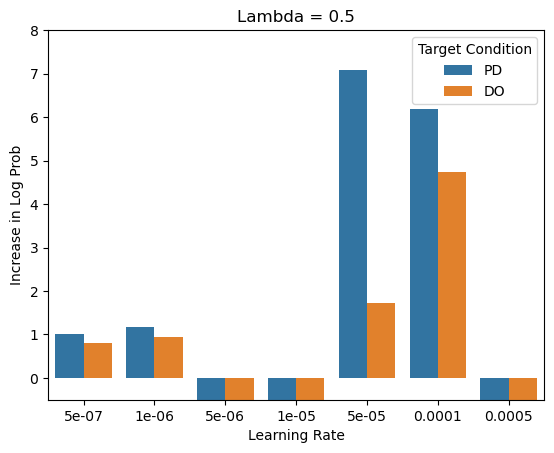

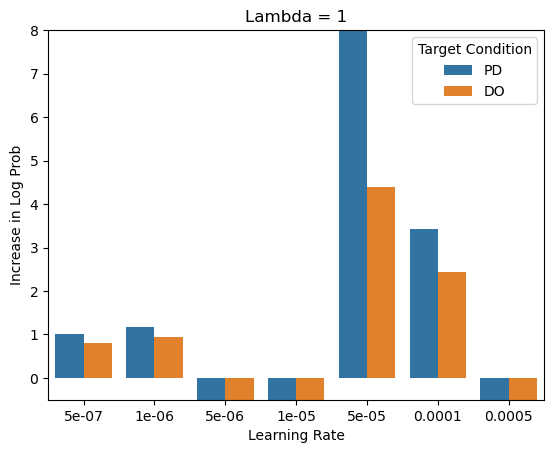

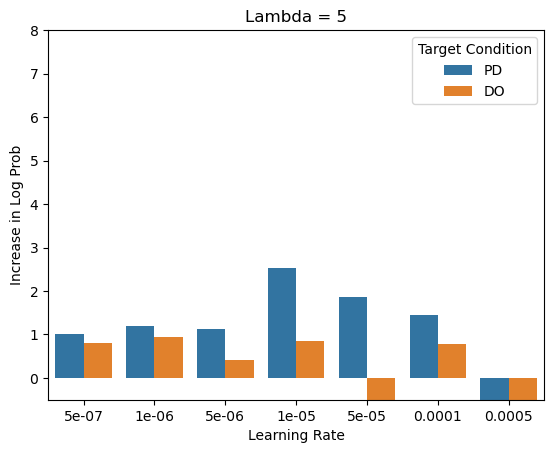

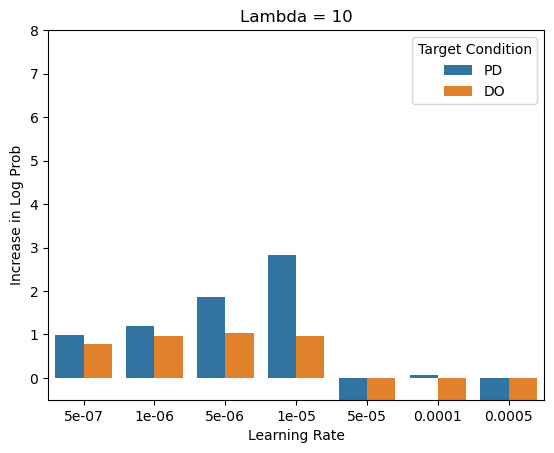

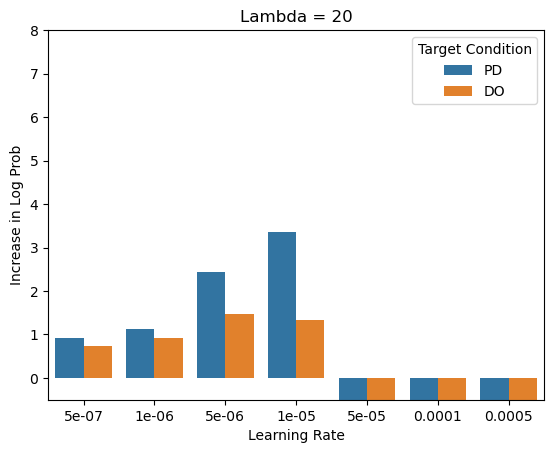

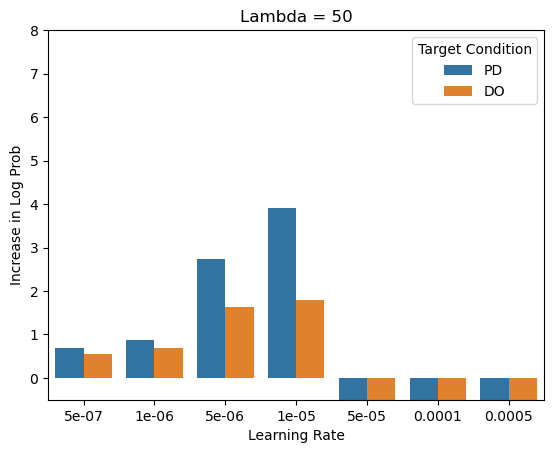

In [24]:
df = pd.read_csv(f'{root_dir}fine-tuning/Hyperparameter/Hypersearch_large_with_padding_big.csv')
# iterate and change the large negative values to -0.5
df.loc[df['PD']<0, 'PD'] = -0.5
df.loc[df['DO']<0, 'DO'] = -0.5

for LAMB in [0.1, 0.5, 1, 5, 10, 20, 50]:
    df_sub = df[df['lambda'] == LAMB][['lr','PD','DO']]
    df_melted = df_sub.melt(id_vars = 'lr', var_name='Target Condition', value_name='Priming Dev')
    sns.barplot(data=df_melted, x='lr', y='Priming Dev', hue='Target Condition')
    plt.ylim(-0.5, 8)
    plt.xlabel('Learning Rate')
    plt.ylabel('Increase in Log Prob')
    plt.title(f'Lambda = {LAMB}')
    plt.show()